In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import datetime as dt

In [ ]:
stocks = ['AMZN', 'MSFT', 'FB', 'GOOG']
start = dt.datetime.today() - dt.timedelta(365)
end = dt.datetime.today()
close_price = pd.DataFrame()
ohlcv_data = {}

for ticker in stocks:
    close_price[ticker] = yf.download(tickers=ticker, start=start, end=end, auto_adjust=False)['Adj Close']

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


array([[<Axes: xlabel='Date'>, <Axes: xlabel='Date'>],
       [<Axes: xlabel='Date'>, <Axes: xlabel='Date'>]], dtype=object)

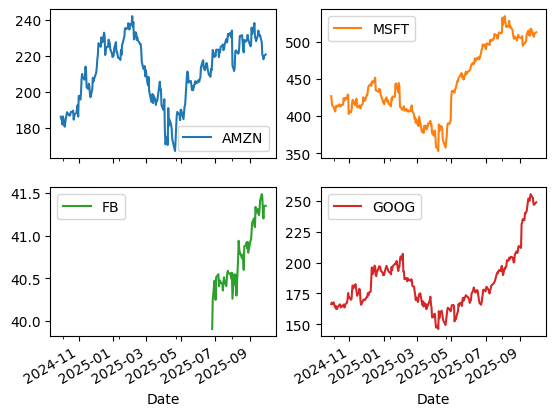

In [3]:
close_price.plot(subplots=True, layout=(2, 2))

In [4]:
daily_returns = close_price.pct_change()
coupound_daily_return = (1 + daily_returns).cumprod()

<Axes: xlabel='Date'>

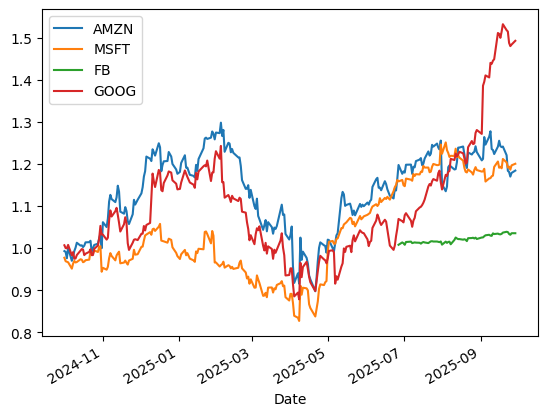

In [5]:
coupound_daily_return.plot()

<BarContainer object of 4 artists>

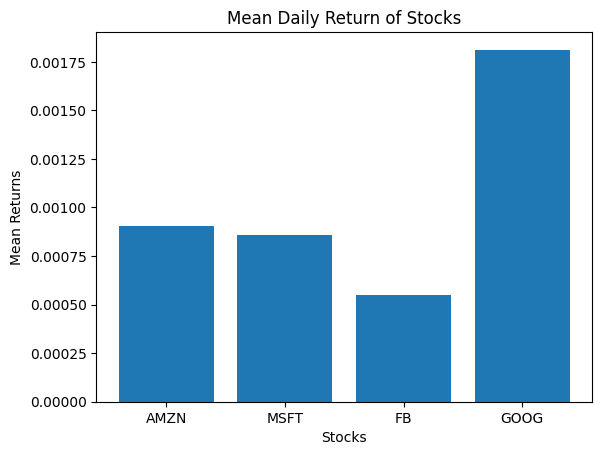

In [6]:
fig, ax = plt.subplots()
ax.set(title='Mean Daily Return of Stocks', xlabel='Stocks', ylabel='Mean Returns')
plt.bar(x=daily_returns.columns, height=daily_returns.mean())

In [7]:
# Filling NaN values
# bfill (backward fill), ffill (forward fill)
print(close_price.fillna(method='bfill', axis=0)) # 0: rows
print(close_price.fillna(method='bfill', axis=1)) # 1: columns

                  AMZN        MSFT         FB        GOOG
Date                                                     
2024-09-30  186.330002  427.093567  39.910000  166.461441
2024-10-01  185.130005  417.555206  39.910000  167.686096
2024-10-02  184.759995  414.021729  39.910000  166.580917
2024-10-03  181.960007  413.436157  39.910000  166.481369
2024-10-04  186.509995  412.959686  39.910000  167.825470
...                ...         ...        ...         ...
2025-09-23  220.710007  509.230011  41.453999  252.339996
2025-09-24  220.210007  510.149994  41.279999  247.830002
2025-09-25  218.149994  507.029999  41.200001  246.570007
2025-09-26  219.779999  511.459991  41.348000  247.179993
2025-09-29  220.809998  513.059998  41.347698  248.669998

[250 rows x 4 columns]
                  AMZN        MSFT          FB        GOOG
Date                                                      
2024-09-30  186.330002  427.093567  166.461441  166.461441
2024-10-01  185.130005  417.555206  167.68609

/var/folders/w5/18qdbhzs6rx3_c589r7xzzsw0000gn/T/ipykernel_85744/3421895767.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  print(close_price.fillna(method='bfill', axis=0)) # 0: rows
/var/folders/w5/18qdbhzs6rx3_c589r7xzzsw0000gn/T/ipykernel_85744/3421895767.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  print(close_price.fillna(method='bfill', axis=1)) # 1: columns


In [8]:
# Dropping NaN values
print(close_price.dropna(axis=0))
print(close_price.dropna(axis=1))
print(close_price.dropna(axis=0, how='any'))
print(close_price.dropna(axis=0, how='all'))

                  AMZN        MSFT         FB        GOOG
Date                                                     
2025-06-26  217.119995  496.633575  39.910000  174.274231
2025-06-27  223.300003  495.126068  40.249001  178.110809
2025-06-30  219.389999  496.593658  40.473999  177.231598
2025-07-01  220.460007  491.242432  40.394001  176.752029
2025-07-02  219.919998  490.284027  40.250000  179.599472
...                ...         ...        ...         ...
2025-09-23  220.710007  509.230011  41.453999  252.339996
2025-09-24  220.210007  510.149994  41.279999  247.830002
2025-09-25  218.149994  507.029999  41.200001  246.570007
2025-09-26  219.779999  511.459991  41.348000  247.179993
2025-09-29  220.809998  513.059998  41.347698  248.669998

[66 rows x 4 columns]
                  AMZN        MSFT        GOOG
Date                                          
2024-09-30  186.330002  427.093567  166.461441
2024-10-01  185.130005  417.555206  167.686096
2024-10-02  184.759995  414.021729 

In [9]:
print(close_price.describe())

             AMZN        MSFT         FB        GOOG
count  250.000000  250.000000  66.000000  250.000000
mean   211.338400  443.260795  40.768132  183.216369
std     17.651725   46.835748   0.367931   23.003086
min    167.320007  353.329437  39.910000  146.273285
25%    196.722496  410.718140  40.482001  166.633251
50%    213.505005  430.556549  40.721001  176.941849
75%    226.295006  495.094551  41.089250  194.546120
max    242.059998  534.760925  41.484001  255.240005


In [ ]:
daily_returns = np.log(close_price / close_price.shift(1))
print(daily_returns)

daily_returns = close_price.pct_change()
print(daily_returns)

daily_returns = close_price / close_price.shift(1) - 1 # pct_change()
print(daily_returns)

                AMZN      MSFT        FB      GOOG
Date                                              
2024-09-30       NaN       NaN       NaN       NaN
2024-10-01 -0.006461 -0.022586       NaN  0.007330
2024-10-02 -0.002001 -0.008498       NaN -0.006613
2024-10-03 -0.015271 -0.001415       NaN -0.000598
2024-10-04  0.024698 -0.001153       NaN  0.008041
...              ...       ...       ...       ...
2025-09-23 -0.030872 -0.010199 -0.000723 -0.002138
2025-09-24 -0.002268  0.001805 -0.004206 -0.018034
2025-09-25 -0.009399 -0.006135 -0.001940 -0.005097
2025-09-26  0.007444  0.008699  0.003586  0.002471
2025-09-29  0.004676  0.003123 -0.000007  0.006010

[250 rows x 4 columns]
                AMZN      MSFT        FB      GOOG
Date                                              
2024-09-30       NaN       NaN       NaN       NaN
2024-10-01 -0.006440 -0.022333       NaN  0.007357
2024-10-02 -0.001999 -0.008462       NaN -0.006591
2024-10-03 -0.015155 -0.001414       NaN -0.000598
2024-10

### Rolling Operations - Data in Motion

In [11]:
# Simple Moving Average
print(daily_returns.rolling(window=7, min_periods=3).mean())
print(daily_returns.rolling(window=7, min_periods=3).std())
print(daily_returns.rolling(window=7).max())
print(daily_returns.rolling(window=7).min())

                AMZN      MSFT        FB      GOOG
Date                                              
2024-09-30       NaN       NaN       NaN       NaN
2024-10-01       NaN       NaN       NaN       NaN
2024-10-02       NaN       NaN       NaN       NaN
2024-10-03 -0.007865 -0.010737       NaN  0.000056
2024-10-04  0.000353 -0.008341       NaN  0.002061
...              ...       ...       ...       ...
2025-09-23 -0.004617 -0.000133  0.000637  0.006498
2025-09-24 -0.006995 -0.001404 -0.000101 -0.002199
2025-09-25 -0.009948 -0.000526 -0.000188 -0.002732
2025-09-26 -0.007398  0.000447  0.000377 -0.001487
2025-09-29 -0.006488  0.001334  0.000203 -0.002043

[250 rows x 4 columns]
                AMZN      MSFT        FB      GOOG
Date                                              
2024-09-30       NaN       NaN       NaN       NaN
2024-10-01       NaN       NaN       NaN       NaN
2024-10-02       NaN       NaN       NaN       NaN
2024-10-03  0.006693  0.010643       NaN  0.006997
2024-10

In [12]:
# Exponential Moving Average
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.ewm.html
# com: alpha = 1 / (1 + com), for com >= 0
print(daily_returns.ewm(com=7, min_periods=7).mean())

                AMZN      MSFT        FB      GOOG
Date                                              
2024-09-30       NaN       NaN       NaN       NaN
2024-10-01       NaN       NaN       NaN       NaN
2024-10-02       NaN       NaN       NaN       NaN
2024-10-03       NaN       NaN       NaN       NaN
2024-10-04       NaN       NaN       NaN       NaN
...              ...       ...       ...       ...
2025-09-23 -0.005318  0.000072  0.000737  0.006218
2025-09-24 -0.004937  0.000289  0.000120  0.003207
2025-09-25 -0.005489 -0.000512 -0.000137  0.002170
2025-09-26 -0.003869  0.000644  0.000329  0.002208
2025-09-29 -0.002799  0.000955  0.000287  0.002686

[250 rows x 4 columns]
